# Brazilian E-Commerce Customer Analytics

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [5]:
rfm = pd.read_csv('/content/rfm_table.csv')
revenue= pd.read_csv('/content/customer_revenue.csv')
cohort = pd.read_csv('/content/cohort.csv')

## 3. Data Preparation

In [6]:
rfm['M_score'] = pd.qcut(
    rfm['customer_monetary'],
    q=5,
    labels=[1,2,3,4,5]
)
rfm['R_score'] = pd.qcut(
    rfm['customer_recency'],
    q=5,
    labels=[5,4,3,2,1]
)
rfm['F_score']=np.select(
    [rfm['customer_frequency']==1,
    rfm['customer_frequency']==2,
    rfm['customer_frequency']==3,
    rfm['customer_frequency'].between (4,5),
    rfm['customer_frequency']==6],
    [1,2,3,4,5]
)

## 4. RFM Analysis

In [7]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [8]:
rfm['Customer_Segment'] = np.select(
    [
        (rfm['R_score'] >= 4) & (rfm['F_score'] >= 4) & (rfm['M_score'] >= 4),

        (rfm['R_score'] >= 3) & (rfm['F_score'] >= 3),

        (rfm['R_score'] >= 4) & (rfm['F_score'] == 2),

        (rfm['R_score'] <= 2) & (rfm['F_score'] >= 3),

        (rfm['R_score'] == 1) & (rfm['F_score'] == 1)
    ],
    [
        'Champions',
        'Loyal Customers',
        'Potential Loyalists',
        'At Risk',
        'Lost'
    ],
    default='Others'
)

In [ ]:
rfm['Customer_Segment'] = np.select(
    [
        (rfm['R_score'] >= 4) & (rfm['M_score'] >= 4),
        (rfm['R_score'] >= 4) & (rfm['M_score'] <= 3),
        (rfm['R_score'] <= 2) & (rfm['M_score'] >= 4),
        (rfm['R_score'] <= 2) & (rfm['M_score'] <= 2)
    ],
    [
        'Champions',
        'Recent Customers',
        'At Risk High Value',
        'Lost Customers'
    ],
    default='Regular Customers'
)

## 5. Pareto Analysis

In [9]:
revenue=revenue.sort_values(by='revenue_per_customer',ascending=False)
revenue = revenue.reset_index(drop=True)
revenue['Cumulative_Revenue'] = revenue['revenue_per_customer'].cumsum()
total_revenue = revenue['revenue_per_customer'].sum()
revenue['Cumulative_Revenue_%'] = ((revenue['Cumulative_Revenue']/total_revenue)*100).round(2)
total_customers=len(revenue)
revenue['Customer_%']=((revenue.index+1)/total_customers)*100
pareto = revenue[
    revenue['Cumulative_Revenue_%'] >= 80
].iloc[0]
print(f"Top {pareto['Customer_%']:.2f}% of customers generate 80% of revenue.")

Top 44.90% of customers generate 80% of revenue.


In [10]:

# Create 100 percentile buckets
revenue["Customer Bucket"] = (revenue["Customer_%"]).apply(lambda x: int(x) + 1)

# Group by bucket
pareto_summary = (
    revenue.groupby("Customer Bucket", as_index=False)
    .agg({
        "revenue_per_customer": "sum",
        "Cumulative_Revenue_%": "max"
    })
)

pareto_summary.rename(columns={
    "revenue_per_customer": "Revenue",
    "Cumulative_Revenue_%": "Cumulative Revenue %"
}, inplace=True)

pareto_summary.to_csv("pareto_summary.csv", index=False)

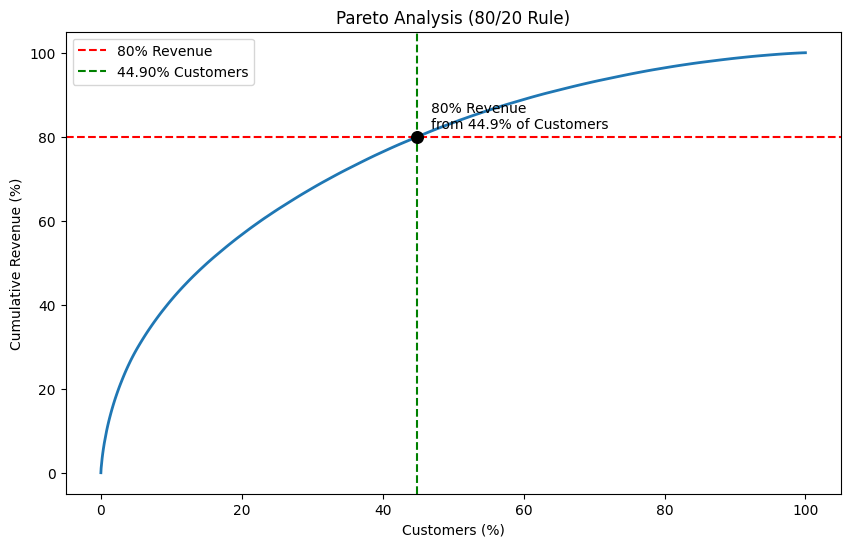

Business Insight: The top 44.90% of customers contribute 80% of the total revenue.


In [11]:
plt.figure(figsize=(10,6))

# Pareto Curve
plt.plot(
    revenue['Customer_%'],
    revenue['Cumulative_Revenue_%'],
    linewidth=2
)

# Horizontal 80% line
plt.axhline(
    y=80,
    color='red',
    linestyle='--',
    label='80% Revenue'
)

# Vertical line where 80% is reached
plt.axvline(
    x=pareto['Customer_%'],
    color='green',
    linestyle='--',
    label=f"{pareto['Customer_%']:.2f}% Customers"
)

# Mark the intersection point
plt.scatter(
    pareto['Customer_%'],
    80,
    color='black',
    s=70,
    zorder=5
)

# Add annotation
plt.text(
    pareto['Customer_%'] + 2,
    82,
    f"80% Revenue\nfrom {pareto['Customer_%']:.1f}% of Customers",
    fontsize=10
)
plt.xlabel('Customers (%)')
plt.ylabel('Cumulative Revenue (%)')
plt.title('Pareto Analysis (80/20 Rule)')

plt.legend()

plt.show()
print(f"Business Insight: The top {pareto['Customer_%']:.2f}% of customers contribute 80% of the total revenue.")

## 6. Cohort Retention Analysis

In [12]:
cohort['cohort_month'] = pd.to_datetime(cohort['cohort_month'])
cohort['order_month'] = pd.to_datetime(cohort['order_month'])
cohort['cohort_year'] = cohort['cohort_month'].dt.year
cohort['cohort_month_num'] = cohort['cohort_month'].dt.month

cohort['order_year'] = cohort['order_month'].dt.year
cohort['order_month_num'] = cohort['order_month'].dt.month

In [13]:
year_diff = cohort['order_year'] - cohort['cohort_year']

month_diff = cohort['order_month_num'] - cohort['cohort_month_num']

cohort['Cohort_Index'] = (
    year_diff * 12
    + month_diff
    + 1
)
cohort_data = cohort.groupby(
    ['cohort_month', 'Cohort_Index']
)['customer_unique_id'].nunique().reset_index()

In [15]:
cohort_counts = cohort_data.pivot(
    index='cohort_month',
    columns='Cohort_Index',
    values='customer_unique_id'
)
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(
    cohort_size,
    axis=0
)
retention = retention * 100
retention_new = (
    retention.reset_index()
    .melt(
        id_vars="cohort_month",
        var_name="Cohort_Index",
        value_name="Retention"
    )
)

retention_new["cohort_month"] = pd.to_datetime(
    retention_new["cohort_month"]
).dt.strftime("%b %Y")
retention_new["Cohort_Index"] = retention_new["Cohort_Index"].astype(int)
retention_new["Month_Sort"] = pd.to_datetime(
    retention_new["cohort_month"],
    format="%b %Y"
)

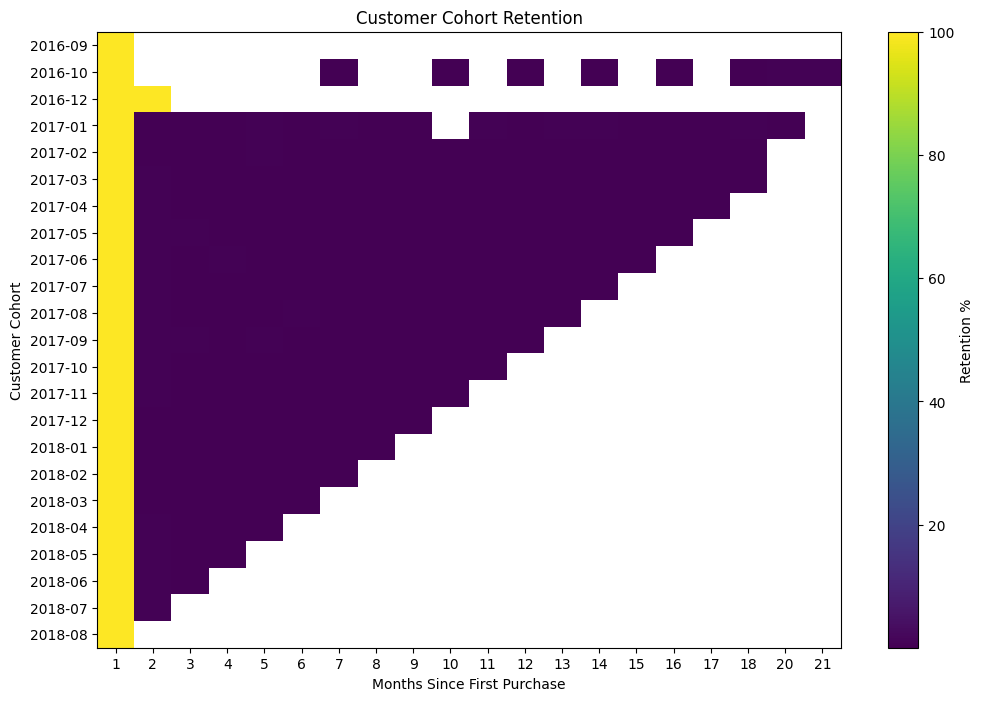

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(retention, aspect='auto')

plt.colorbar(label='Retention %')

plt.xticks(
    range(len(retention.columns)),
    retention.columns
)

plt.yticks(
    range(len(retention.index)),
    retention.index.strftime('%Y-%m')
)

plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer Cohort')
plt.title('Customer Cohort Retention')

plt.show()

## Export Results

In [17]:
rfm.to_csv('rfm_final.csv', index=False)
pareto_summary.to_csv("pareto_summary.csv", index=False)
retention_new.to_csv("retention_final2.csv", index=False)